# Importing important libraries


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv('customer_segmentation.csv')

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [81]:
df.shape

(2216, 29)

# Lets start cleaning the data.

In [82]:
df[df.isna().any(axis=1)] # got some nan vals

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [83]:
df = df.dropna()
df.shape

(2216, 29)

In [84]:
df.duplicated().sum().item()

0

In [85]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

# As we can see there are lot of features but we gonna only take those features which will be relevant for performing the Kmeans Clustering

In [86]:
df_subset = df[['ID','Marital_Status','Kidhome','NumStorePurchases']]

# I personally think, with Marital_Status,Kidhome and NumStorePurchases features we can figure out the buying behaviour of a particular person.

In [87]:
df_subset.shape

(2216, 4)

In [88]:
df_subset.head()

,ID,Marital_Status,Kidhome,NumStorePurchases
0,5524,Single,0,4
1,2174,Single,1,2
2,4141,Together,0,10
3,6182,Together,1,4
4,5324,Married,1,6


In [89]:
df_subset.Marital_Status.nunique()

8

In [90]:
df_subset.Marital_Status.value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [91]:
''' here we can see that
 1. Married and together belong to first category
 2. Single, Divorced,Widow and Alone belong to second category
 3. Yolo and absurd cant provide us any intel on that '''

marital_status_map={
     'Married':1,
     'Together':1,
     'Single': 2,
     'Divorced': 2,
     'Widow': 2,
     'Alone':2,
     'Absurd':0,
     'YOLO':0
 }

In [92]:
df_subset['Status'] = df_subset.Marital_Status.map(marital_status_map)

/tmp/ipython-input-3208422891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['Status'] = df_subset.Marital_Status.map(marital_status_map)


In [93]:
df_subset[df_subset['Status'] == 0]

,ID,Marital_Status,Kidhome,NumStorePurchases,Status
2093,7734,Absurd,0,7,0
2134,4369,Absurd,0,6,0
2177,492,YOLO,0,6,0
2202,11133,YOLO,0,6,0


In [94]:
df_subset.drop([2093,2134,2177,2202],inplace=True)

/tmp/ipython-input-4040328560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.drop([2093,2134,2177,2202],inplace=True)


In [95]:
df_subset = df_subset.reset_index(drop=True)

df_subset.shape

(2212, 5)

In [96]:
df_subset = df_subset.drop(columns = ['Marital_Status'])

In [97]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212 entries, 0 to 2211
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 2212 non-null   int64
 1   Kidhome            2212 non-null   int64
 2   NumStorePurchases  2212 non-null   int64
 3   Status             2212 non-null   int64
dtypes: int64(4)
memory usage: 69.3 KB


In [98]:
df_subset.describe()

,ID,Kidhome,NumStorePurchases,Status
count,2212.000000,2212.000000,2212.000000,2212.000000
mean,5587.731917,0.442586,5.800181,1.353526
std,3247.944128,0.537052,3.253616,0.478172
min,0.000000,0.000000,0.000000,1.000000
25%,2814.750000,0.000000,3.000000,1.000000
50%,5458.500000,0.000000,5.000000,1.000000
75%,8421.750000,1.000000,8.000000,2.000000
max,11191.000000,2.000000,13.000000,2.000000


In [99]:
df_subset.head()

,ID,Kidhome,NumStorePurchases,Status
0,5524,0,4,2
1,2174,1,2,2
2,4141,0,10,1
3,6182,1,4,1
4,5324,1,6,1


In [100]:
# lets remove the ID column for interpreting only the numeric column
model_df = df_subset.iloc[:,1:]

model_df

,Kidhome,NumStorePurchases,Status
0,0,4,2
1,1,2,2
2,0,10,1
3,1,4,1
4,1,6,1
...,...,...,...
2207,0,4,1
2208,2,5,1
2209,0,13,2
2210,0,10,1


In [101]:
# feature scaling

scaler = StandardScaler()
normalized = scaler.fit_transform(model_df)

normalized_df = pd.DataFrame(normalized, columns = model_df.columns)
normalized_df.head()

,Kidhome,NumStorePurchases,Status
0,-0.824288,-0.553411,1.352274
1,1.038148,-1.168251,1.352274
2,-0.824288,1.291108,-0.739495
3,1.038148,-0.553411,-0.739495
4,1.038148,0.061428,-0.739495


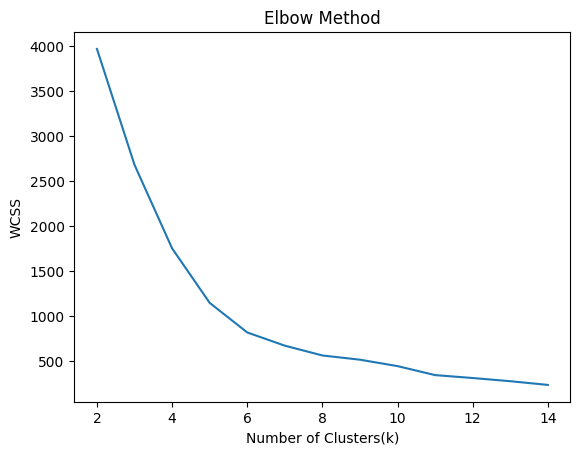

In [103]:
# Fitting K-Means Model

wcss = []

for k in range(2,15):
  kmeans = KMeans(n_clusters = k, n_init = 'auto', random_state = 42)
  kmeans.fit(normalized_df)
  wcss.append(kmeans.inertia_)

plt.plot(range(2,15),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('WCSS')
plt.show()

# Clustering

In [104]:
kmeans = KMeans(n_clusters = 2, n_init = 'auto', random_state = 42)
kmeans.fit(normalized_df)

cluster_df = pd.concat([normalized_df, pd.Series(kmeans.labels_, name = 'cluster_labels')], axis = 1)
cluster_df.head()

,Kidhome,NumStorePurchases,Status,cluster_labels
0,-0.824288,-0.553411,1.352274,0
1,1.038148,-1.168251,1.352274,1
2,-0.824288,1.291108,-0.739495,0
3,1.038148,-0.553411,-0.739495,1
4,1.038148,0.061428,-0.739495,1


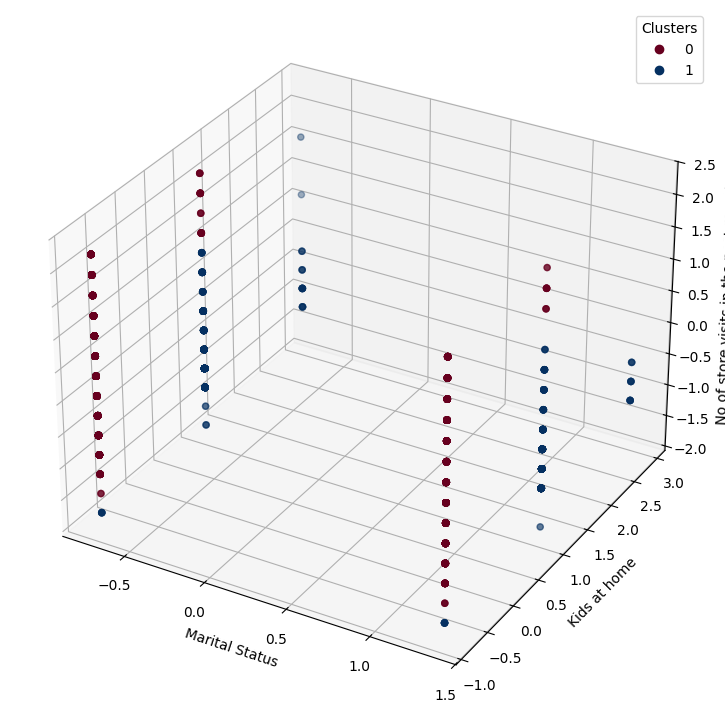

In [108]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (12,7))
ax = Axes3D(fig)
fig.add_axes(ax)


sc = ax.scatter(cluster_df['Status'], cluster_df['Kidhome'], cluster_df['NumStorePurchases'], c= cluster_df['cluster_labels'], cmap = 'RdBu')

ax.set_xlabel('Marital Status')
ax.set_ylabel('Kids at home')
ax.set_zlabel('No of store visits in the past month')

plt.legend(*sc.legend_elements(), title = 'Clusters')
plt.show()

# Cluster 0 : If we recall status = 1 after scaling, was for customers whose marital status was alone or divorced or widowed or single. Here we have Adults who live alone and also single parents. We need to tailor our ads to address the needs of both sets of people.
# Cluster 1 : In this cluster, we have kids living with parents or adults living together. This cluster needs a different type of ad that appeals to their needs.

In [109]:
# The End